In [ ]:
import equinox as eqx
import grain
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from context_flux_no.data import SpatialDownsample, TheWellDataSource
from context_flux_no.models.multiphysics import (
    AbstractMultiphysicsOperator,
    DPOT,
)
from context_flux_no.training.trainer import Trainer
from jaxtyping import Array, Float, PRNGKeyArray


jax.config.update("jax_default_device", jax.devices("gpu")[6])

In [2]:
source = TheWellDataSource(
    "../../data/datasets",
    "euler_multi_quadrants_periodicBC",
    window_size=11,
    exclude_field_names=["pressure"],
)

In [3]:
dataset = (
    grain.MapDataset.source(source)
    .apply(SpatialDownsample(downsample=8))
    .shuffle(10)
    .to_iter_dataset()
)
performance_config = grain.experimental.pick_performance_config(
    ds=dataset, ram_budget_mb=8192, max_workers=None, max_buffer_size=None
)

prefetch_lazy_iter_ds = dataset.mp_prefetch(
    performance_config.multiprocessing_options,
).batch(batch_size=128)

In [4]:
dataiter = iter(prefetch_lazy_iter_ds)
arr = next(dataiter)

In [5]:
(arr.dtype.itemsize * arr.size) / 1e9

0.092274688

In [6]:
arr.shape

(128, 11, 4, 64, 64)

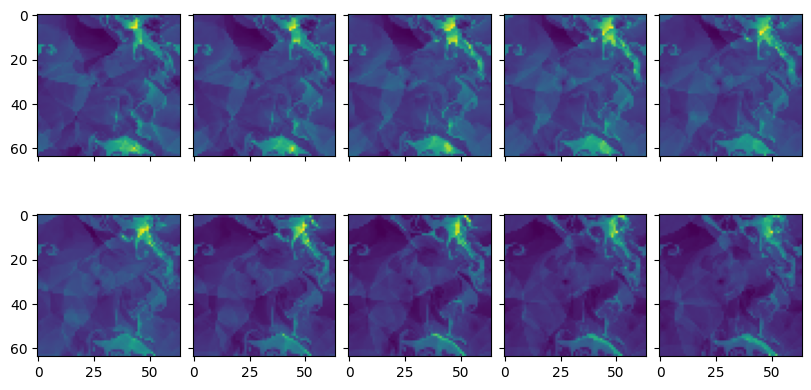

In [9]:
sample_idx = 0
fig, axes = plt.subplots(
    2, 5, figsize=(8, 4), constrained_layout=True, sharex=True, sharey=True
)
for i, ax in enumerate(axes.flat):
    ax.imshow(arr[sample_idx, i, 0])

In [ ]:
arr.shape

(128, 21, 4, 64, 64)

In [ ]:
dpot = DPOT(
    num_spatial_dims=2,
    in_channels=4,
    out_channels=4,
    in_timesteps=10,
    patch_size=(8, 8),
    img_size=(64, 64),
    embedding_dim=256,
    max_frequency_modes=(10, 10),
    fno_depth=5,
    num_blocks=4,
    num_classes=12,
    hidden_dim_patch=256,
    hidden_dim_fno=256,
    hidden_dim_output=32,
    key=jax.random.key(0),
)

In [12]:
eqx.filter_vmap(dpot)(arr[:, :-1])[0].block_until_ready()

Array([[[[ 0.12269744,  0.1182465 ,  0.13093485, ...,  0.13065633,
           0.12747036,  0.13149895],
         [ 0.11999622,  0.1281457 ,  0.13152269, ...,  0.12671871,
           0.11511075,  0.1357075 ],
         [ 0.13292617,  0.13422611,  0.12777561, ...,  0.12881742,
           0.12467884,  0.13942087],
         ...,
         [ 0.13518354,  0.12368563,  0.13243459, ...,  0.12939368,
           0.13412459,  0.12853138],
         [ 0.12193999,  0.14067186,  0.14645992, ...,  0.13198099,
           0.12891121,  0.12876587],
         [ 0.12056635,  0.12992394,  0.13414401, ...,  0.13177463,
           0.13274218,  0.11948536]],

        [[-0.12291457, -0.11910395, -0.105193  , ..., -0.11080626,
          -0.11922828, -0.12339735],
         [-0.11762524, -0.11467223, -0.11471288, ..., -0.10841621,
          -0.13761452, -0.1055356 ],
         [-0.11963731, -0.1068667 , -0.11402626, ..., -0.1194873 ,
          -0.11200091, -0.10990782],
         ...,
         [-0.10085297, -0.11395852

In [19]:
def loss_fn(
    model: AbstractMultiphysicsOperator,
    u: Float[Array, "batch time dim ..."],
    args,
    key: PRNGKeyArray,
) -> tuple[Float[Array, ""], dict]:
    u0, u1 = u[:, :-1], u[:, -1]
    keys = jax.random.split(key, u0.shape[0])
    u1_pred: Float[Array, "batch dim ..."] = eqx.filter_vmap(
        lambda u_, key_: model(u_, args, key=key_)
    )(u0, keys)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


trainer = Trainer(
    optax.adamw(1e-3),
    loss_fn,
    "./",
    None,
    {"entity": "jhko725", "project": "euler_test"},
    config_dict={"model": ""},
)

In [ ]:
trainer.train(dpot, dataloader, None, None, num_steps=500, seed=0)

Step: 1 | Train loss: 5.77877950668335 | Valid loss: 
            None
Step: 2 | Train loss: 5.997730255126953 | Valid loss: 
            None


Step: 3 | Train loss: 5.120358467102051 | Valid loss: 
            None


Step: 4 | Train loss: 1.5844664573669434 | Valid loss: 
            None


Step: 5 | Train loss: 1.7273378372192383 | Valid loss: 
            None


Step: 6 | Train loss: 1.9840843677520752 | Valid loss: 
            None


...

Step: 15 | Train loss: 0.9491835832595825 | Valid loss: 
            None


Step: 16 | Train loss: 0.7055436372756958 | Valid loss: 
            None


Step: 17 | Train loss: 0.3134033977985382 | Valid loss: 
            None


Step: 18 | Train loss: 0.4194553792476654 | Valid loss: 
            None


Step: 19 | Train loss: 0.3127429485321045 | Valid loss: 
            None
Step: 20 | Train loss: 0.46246176958084106 | Valid loss: 
            None
